<a href="https://colab.research.google.com/github/Shamik-DedSec/Chat-App/blob/main/Lab%202%20Shamik%20Shoeb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Lab Assignment 02
Topic: Linear Regression on Housing Dataset

# Q1. Dataset Exploration & Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [ ]:
from google.colab import files

uploaded=files.upload()
df=pd.read_csv("HousingData.csv")

print(df.head(10))
print("\nShape of dataset:",df.shape)

Saving HousingData.csv to HousingData (3).csv
      CRIM    ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575   65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421   78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185   61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998   45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147   54.2  6.0622    3  222     18.7   
5  0.02985   0.0   2.18   0.0  0.458  6.430   58.7  6.0622    3  222     18.7   
6  0.08829  12.5   7.87   NaN  0.524  6.012   66.6  5.5605    5  311     15.2   
7  0.14455  12.5   7.87   0.0  0.524  6.172   96.1  5.9505    5  311     15.2   
8  0.21124  12.5   7.87   0.0  0.524  5.631  100.0  6.0821    5  311     15.2   
9  0.17004  12.5   7.87   NaN  0.524  6.004   85.9  6.5921    5  311     15.2   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   

In [ ]:
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  506.000000   
mean     3.611874   11.211934   11.083992    0.069959    0.554695    6.284634   
std      8.720192   23.388876    6.835896    0.255340    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.081900    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.253715    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.560263   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  486.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.518519    3.795043    9.549407  408.237154   18.455534  356.674032   
std     27.999513    2.1057

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [ ]:
df=df.fillna(df.median(numeric_only=True))

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
df=df.rename(columns={"MEDV":"PRICE"})

X=df.drop("PRICE",axis=1)
y=df["PRICE"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(y.name)

print("\nX shape:",X.shape)
print("y shape:",y.shape)

Input Features:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Target Variable:
PRICE

X shape: (506, 13)
y shape: (506,)


Observation

The dataset contains 506 samples and 13 input features. The target variable is PRICE. Missing values were checked and replaced using the median value of each numerical feature. After preprocessing, the dataset contains no missing values.

# Q2. Build & Evaluate Linear Regression Model

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)

Training data: (404, 13)
Testing data: (102, 13)


In [ ]:
model=LinearRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Model training completed")

Model training completed


In [ ]:
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred)

results=pd.DataFrame({
    "Metric":["R²","RMSE","MSE","MAE"],
    "Value":[r2,rmse,mse,mae]
})

print(results)

  Metric      Value
0     R²   0.659101
1   RMSE   4.999938
2    MSE  24.999385
3    MAE   3.148737


In [ ]:
coefficients=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

print(coefficients)

    Feature  Coefficient
0      CRIM    -0.112574
1        ZN     0.028179
2     INDUS    -0.025656
3      CHAS     3.279482
4       NOX   -15.978338
5        RM     4.717140
6       AGE    -0.018190
7       DIS    -1.506219
8       RAD     0.218217
9       TAX    -0.009054
10  PTRATIO    -0.890010
11        B     0.012033
12    LSTAT    -0.444167


In [ ]:
largest_positive=coefficients.loc[
    coefficients["Coefficient"].idxmax()
]

largest_negative=coefficients.loc[
    coefficients["Coefficient"].idxmin()
]

print("Largest Positive Coefficient:")
print(largest_positive)

print("\nLargest Negative Coefficient:")
print(largest_negative)

Largest Positive Coefficient:
Feature             RM
Coefficient    4.71714
Name: 5, dtype: object

Largest Negative Coefficient:
Feature              NOX
Coefficient   -15.978338
Name: 4, dtype: object


Model Interpretation

The Linear Regression model is used to predict house prices using 13 input features. The R² score shows how well the model explains the variation in house prices. Lower RMSE, MSE and MAE indicate smaller prediction errors. A positive coefficient means that an increase in that feature tends to increase the predicted house price, while a negative coefficient means that an increase in that feature tends to decrease the predicted house price, when other features are kept constant.

# Q3. Regression Visualization & Interpretation

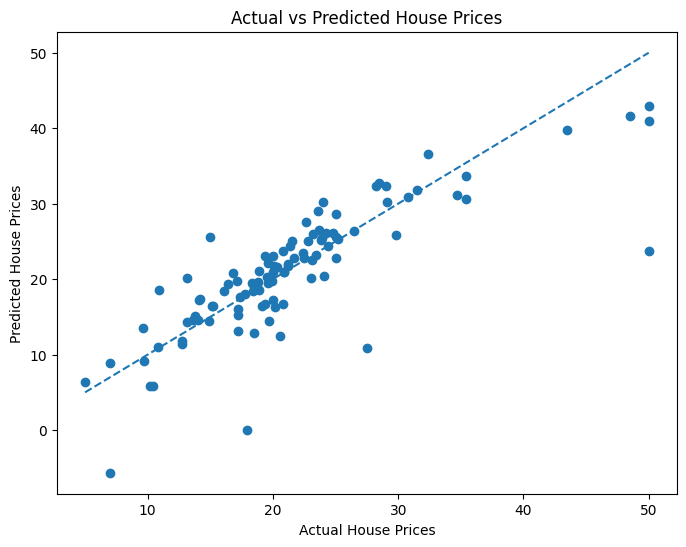

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

Observation

The points are generally close to the diagonal line, which means that the predicted house prices are reasonably close to the actual prices. Points farther away from the line represent larger prediction errors.

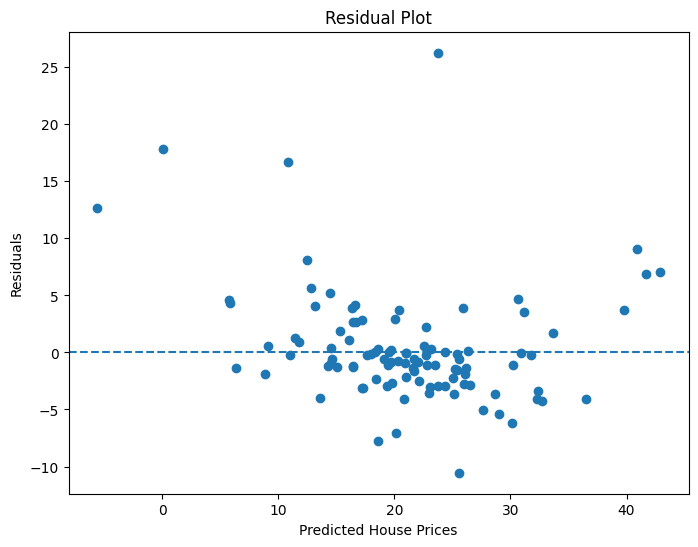

In [ ]:
residuals=y_test-y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred,residuals)

plt.axhline(y=0,linestyle="--")

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Residual Observation

The residuals are distributed around the zero line. Most residuals are relatively close to zero, while some larger residuals are present. This shows that the model makes small errors for many observations but has larger errors for some house prices.